# Land Use Classification from Satellite Images  

Group 4: Teresa Alvarez, Vikram Bhatt, Alessandro Cristofolini, Matteo Khoueiri, Dominique Robson, & Pengchong Zhao

---

## Executive Summary

In this project, we address the problem of land use classification using satellite image patches from the EuroSAT RGB dataset. The objective is to automatically classify land cover types (e.g., Forest, Residential, River, Industrial) from aerial imagery.

We compare two approaches:

1. A classical computer vision baseline using HOG features and a linear SVM.
2. A deep learning approach using transfer learning with a pretrained Convolutional Neural Network (CNN).


----
# 1. Business / Research Question

## Problem

Can satellite image patches be automatically classified into land use categories to support environmental monitoring and urban planning?

## Motivation

Manual annotation of satellite imagery is costly and time-consuming. Automated classification can:

- Accelerate large-scale analysis
- Support planning and monitoring
- Flag uncertain cases for human review

The system is intended as decision support rather than full automation.

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scikit-image pillow tqdm


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: /Users/dominiquekamilrobson/tmdb_project_clean/.venv/bin/python -m pip install --upgrade pip


In [2]:
from pathlib import Path
import random
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Assistant
This error occurs because the 'pandas' module is not installed in your current Python environment. The error message "ModuleNotFoundError: No module named 'pandas'" indicates that Python cannot find the pandas library that your code is trying to import.

Would you like me to provide the corrected code?

# Assistant
This error occurs because the 'pandas' module is not installed in your current Python environment. The error message "ModuleNotFoundError: No module named 'pandas'" indicates that Python cannot find the pandas library that your code is trying to import.

Would you like me to provide the corrected code?

# 2. Dataset

## 2.1 Source

We use the EuroSAT RGB dataset:

- ~27,000 satellite image patches
- 10 land use classes
- RGB format, 64×64 resolution
- Images organized in class-based folders

## 2.2 Classes

- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake

Each image represents a satellite patch labeled with its dominant land use type.

In [3]:
DATA_DIR = Path("img")

# Verificar que existe
if not DATA_DIR.exists():
    raise FileNotFoundError(f"{DATA_DIR} not found")

# Detectar clases (subcarpetas)
classes = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])

print(f"Number of classes detected: {len(classes)}")
print("Classes:")
for c in classes:
    print("-", c)

Number of classes detected: 10
Classes:
- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake


In [4]:
image_extensions = {".jpg", ".jpeg", ".png"}

data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    data.append({
        "class": cls,
        "num_images": len(images)
    })

df_counts = pd.DataFrame(data).sort_values("class")
total_images = df_counts["num_images"].sum()

print(df_counts)
print("\nTotal images:", total_images)

                  class  num_images
0            AnnualCrop        3000
1                Forest        3000
2  HerbaceousVegetation        3000
3               Highway        2500
4            Industrial        2500
5               Pasture        2000
6         PermanentCrop        2500
7           Residential        3000
8                 River        2500
9               SeaLake        3000

Total images: 27000


## 2.3 Visualization of classes

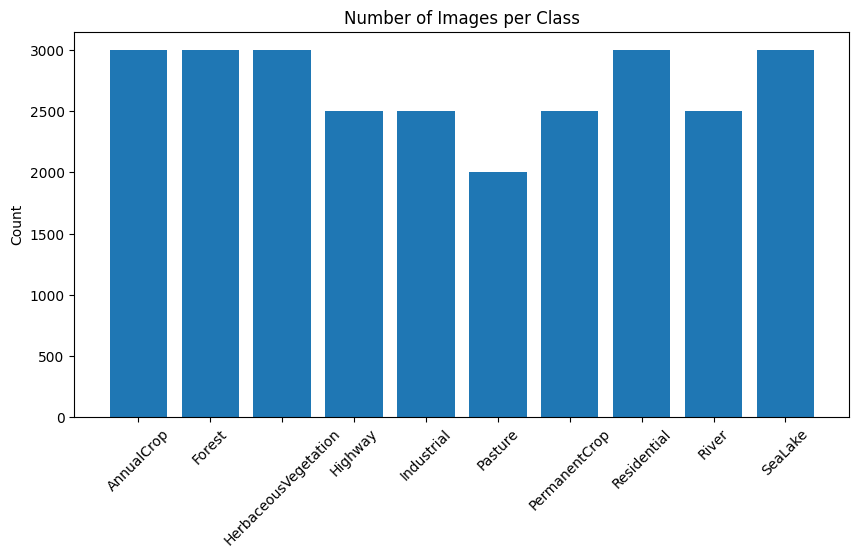

In [5]:
plt.figure(figsize=(10,5))
plt.bar(df_counts["class"], df_counts["num_images"])
plt.xticks(rotation=45)
plt.title("Number of Images per Class")
plt.ylabel("Count")
plt.show()

## 2.4 Corrupted image check

No images are corrupter out of the 27000

In [6]:
corrupted = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    sample_images = random.sample(images, min(200, len(images)))
    
    for img_path in sample_images:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted.append(img_path)

print("Number of corrupted images found:", len(corrupted))

Number of corrupted images found: 0


## Showing sample images

In [7]:
all_data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    for img_path in images:
        all_data.append({
            "path": str(img_path),
            "label": cls
        })

df_all = pd.DataFrame(all_data)

print("Total images indexed:", len(df_all))
df_all.head()

#guardar dataframe por si acaso
df_all.to_csv("csv/image_data.csv", index=False)

Total images indexed: 27000


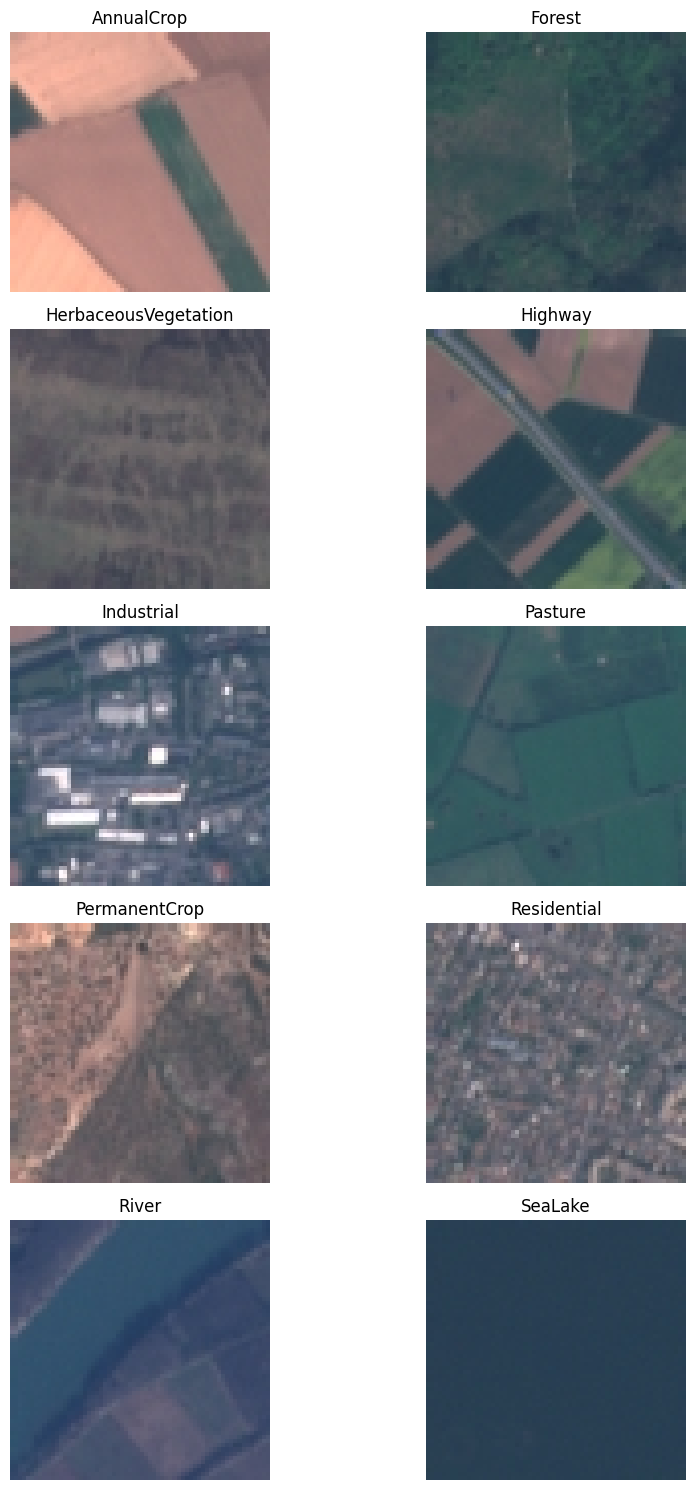

In [8]:
fig, axes = plt.subplots(5, 2, figsize=(10,15))

for ax, cls in zip(axes.flat, classes):
    sample_path = df_all[df_all["label"] == cls]["path"].sample(1).values[0]
    img = plt.imread(sample_path)
    
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2.5 Dataset Indexing

To prepare the dataset for model training, we construct a master DataFrame containing:

- The image file path
- The corresponding class label

This structured representation will allow us to perform a reproducible train/validation/test split while ensuring consistency across models.

In [9]:
all_data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    for img_path in images:
        all_data.append({
            "path": str(img_path),
            "label": cls
        })

df_all = pd.DataFrame(all_data)

print("Total images indexed:", len(df_all))
df_all.head()

#guardar dataframe por si acaso
df_all.to_csv("csv/image_data.csv", index=False)

Total images indexed: 27000


In [10]:
df_all["label"].value_counts()

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
Industrial              2500
PermanentCrop           2500
River                   2500
Pasture                 2000
Name: count, dtype: int64

# 3. Experimental Setup

## 3.1 Train / Validation / Test Split

The dataset is split into:

- 70% Training
- 15% Validation
- 15% Test

The split is stratified by class to preserve class balance.

A fixed random seed ensures reproducibility.

In [11]:
#Codificar etiquetas a números
label_encoder = LabelEncoder()

df_all["label_encoded"] = label_encoder.fit_transform(df_all["label"])

num_classes = len(label_encoder.classes_)

print("Number of classes:", num_classes)
print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Number of classes: 10
Class mapping:
0 -> AnnualCrop
1 -> Forest
2 -> HerbaceousVegetation
3 -> Highway
4 -> Industrial
5 -> Pasture
6 -> PermanentCrop
7 -> Residential
8 -> River
9 -> SeaLake


In [12]:
SEED = 42

#train vs temp (30% para temp)
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["label_encoded"],
    random_state=SEED
)

# Dividir temp en validation (15%) y test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_encoded"],
    random_state=SEED
)

#verify size of splits
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 18900
Validation size: 4050
Test size: 4050


In [13]:
print("Train distribution:\n", train_df["label"].value_counts(normalize=True))
print("\nValidation distribution:\n", val_df["label"].value_counts(normalize=True))
print("\nTest distribution:\n", test_df["label"].value_counts(normalize=True))

Train distribution:
 label
Residential             0.111111
SeaLake                 0.111111
AnnualCrop              0.111111
Forest                  0.111111
HerbaceousVegetation    0.111111
PermanentCrop           0.092593
Industrial              0.092593
Highway                 0.092593
River                   0.092593
Pasture                 0.074074
Name: proportion, dtype: float64

Validation distribution:
 label
SeaLake                 0.111111
HerbaceousVegetation    0.111111
Forest                  0.111111
AnnualCrop              0.111111
Residential             0.111111
Highway                 0.092593
Industrial              0.092593
PermanentCrop           0.092593
River                   0.092593
Pasture                 0.074074
Name: proportion, dtype: float64

Test distribution:
 label
SeaLake                 0.111111
AnnualCrop              0.111111
Residential             0.111111
Forest                  0.111111
HerbaceousVegetation    0.111111
PermanentCrop         

In [14]:
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

df_splits = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

df_splits.head(),df_splits["split"].value_counts()

(                                   path        label  label_encoded  split
 0  img/Residential/Residential_2598.jpg  Residential              7  train
 1          img/SeaLake/SeaLake_2011.jpg      SeaLake              9  train
 2  img/Residential/Residential_1100.jpg  Residential              7  train
 3    img/AnnualCrop/AnnualCrop_1970.jpg   AnnualCrop              0  train
 4             img/Forest/Forest_318.jpg       Forest              1  train,
 split
 train    18900
 val       4050
 test      4050
 Name: count, dtype: int64)

In [15]:
train_df.to_csv("csv/train_data.csv", index=False)
val_df.to_csv("csv/val_data.csv", index=False) 
test_df.to_csv("csv/test_data.csv", index=False)

df_splits.to_csv("csv/splits_data.csv", index=False)

## 3.2 Metrics functions

### Confusion matrix

In [16]:
def plot_confusion_matrix(y_true, y_pred, class_names, normalize=False):
    """
    Plots confusion matrix.
    
    Parameters:
    - y_true: true labels
    - y_pred: predicted labels
    - class_names: list of class names
    - normalize: if True, show percentages instead of raw counts
    """
    
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Model evaluations

In [17]:
def evaluate_model(y_true, y_pred, class_names, model_name="Model"):
    """
    Computes and prints evaluation metrics.
    Returns dictionary with results.
    """
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    
    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {f1_macro:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion matrices
    plot_confusion_matrix(y_true, y_pred, class_names, normalize=False)
    plot_confusion_matrix(y_true, y_pred, class_names, normalize=True)
    
    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": f1_macro
    }

### Comparative table

In [18]:
def compare_models(results_list):
    """
    Creates comparison table from evaluation results.
    
    results_list: list of dictionaries returned by evaluate_model()
    """
    
    results_df = pd.DataFrame(results_list)
    results_df = results_df.set_index("model")
    
    print("\n===== Model Comparison =====")
    display(results_df)
    
    return results_df

# 4. Baseline Model: Random Forest

## 4.1 Feature Extraction: HOG Descriptors

In [19]:
from skimage.feature import hog
from PIL import Image
import numpy as np
from tqdm import tqdm

def extract_hog_features(df, pixels_per_cell=(8,8), cells_per_block=(2,2), orientations=9):
    """
    Extracts HOG feature vectors for all images in df.
    Returns X: numpy array of shape (n_images, n_features)
    """
    features = []
    for img_path in tqdm(df["path"], desc="Extracting HOG features"):
        img = np.array(Image.open(img_path).convert("RGB"))
        hog_vec = hog(
            img,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            channel_axis=-1
        )
        features.append(hog_vec)
    return np.array(features)

print("Extracting HOG features...")
X_train_hog = extract_hog_features(train_df)
X_val_hog   = extract_hog_features(val_df)
X_test_hog  = extract_hog_features(test_df)

Y_train = train_df["label_encoded"].values
Y_val   = val_df["label_encoded"].values
Y_test  = test_df["label_encoded"].values

print(f"\nHOG feature vector length: {X_train_hog.shape[1]}")
print(f"Train: {X_train_hog.shape} | Val: {X_val_hog.shape} | Test: {X_test_hog.shape}")

Extracting HOG features...


Extracting HOG features: 100%|█████████████████████████████████████████████████████████████████████████████████████| 4050/4050 [00:04<00:00, 1000.31it/s]


HOG feature vector length: 1764
Train: (18900, 1764) | Val: (4050, 1764) | Test: (4050, 1764)


## 4.2 Visualising HOG Features

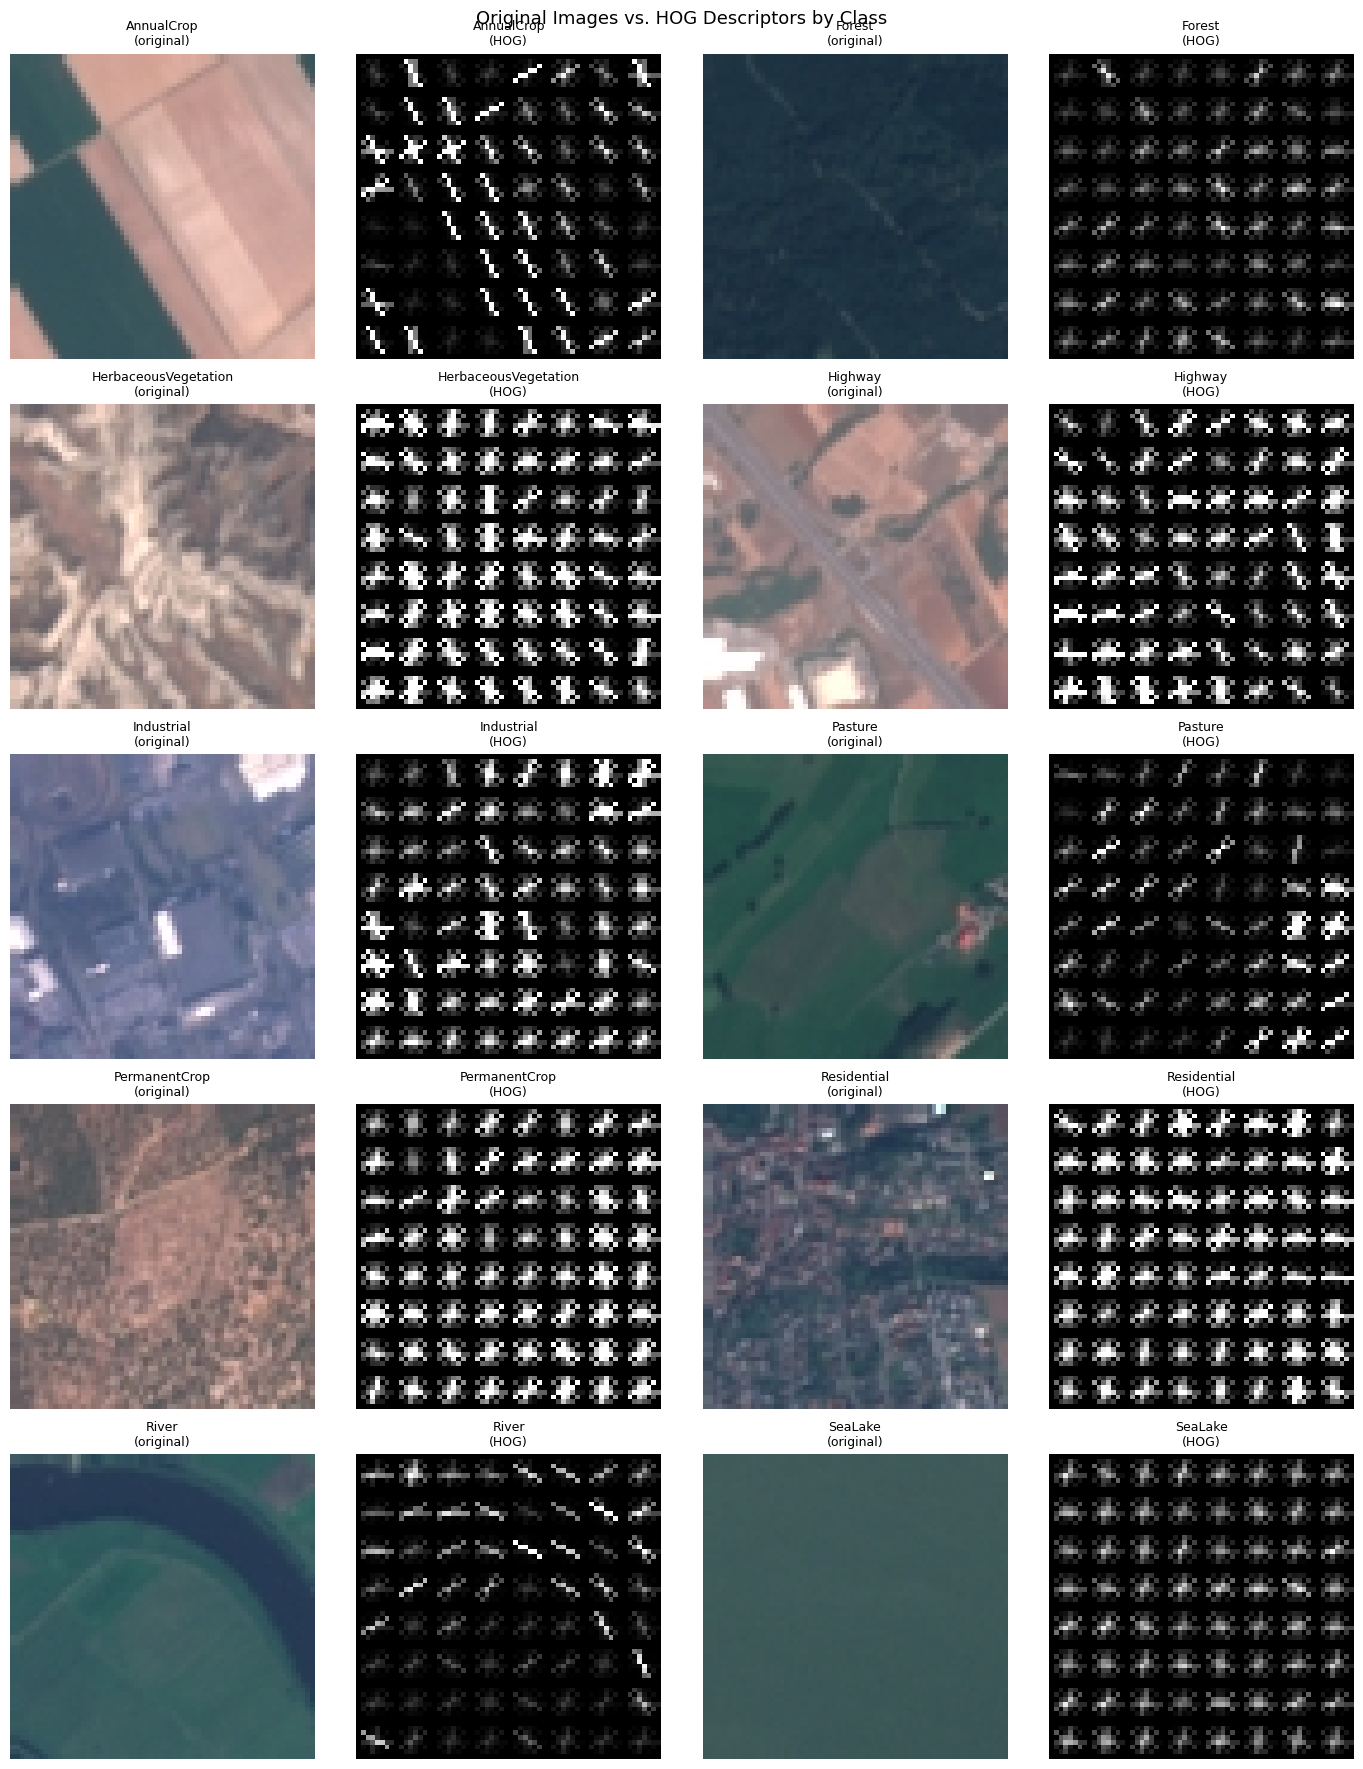

In [20]:
from skimage.feature import hog
from skimage import exposure

fig, axes = plt.subplots(5, 4, figsize=(14, 18))

for idx, cls in enumerate(classes):
    row    = idx // 2
    col_img = (idx % 2) * 2
    col_hog = col_img + 1

    sample_path = train_df[train_df["label"] == cls]["path"].sample(1, random_state=42).values[0]
    img = np.array(Image.open(sample_path).convert("RGB"))

    hog_vec, hog_img = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        channel_axis=-1,
        visualize=True
    )
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[row, col_img].imshow(img)
    axes[row, col_img].set_title(f"{cls}\n(original)", fontsize=9)
    axes[row, col_img].axis("off")

    axes[row, col_hog].imshow(hog_img_rescaled, cmap="gray")
    axes[row, col_hog].set_title(f"{cls}\n(HOG)", fontsize=9)
    axes[row, col_hog].axis("off")

plt.suptitle("Original Images vs. HOG Descriptors by Class", fontsize=13)
plt.tight_layout()
plt.show()

## 4.3 Baseline Random Forest (No Tuning)

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_hog, Y_train)

print(f"OOB Score (baseline):  {rf_baseline.oob_score_:.4f}")

y_pred_baseline = rf_baseline.predict(X_test_hog)
acc_baseline    = accuracy_score(Y_test, y_pred_baseline)
print(f"Test Accuracy (baseline): {acc_baseline:.4f}")

OOB Score (baseline):  0.5141
Test Accuracy (baseline): 0.5588



===== RF Baseline Evaluation =====
Accuracy: 0.5588
Macro-F1: 0.5134

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.51      0.72      0.60       450
              Forest       0.69      0.88      0.77       450
HerbaceousVegetation       0.33      0.41      0.36       450
             Highway       0.59      0.56      0.57       375
          Industrial       0.41      0.29      0.34       375
             Pasture       0.37      0.10      0.16       300
       PermanentCrop       0.25      0.15      0.19       375
         Residential       0.59      0.83      0.69       450
               River       0.63      0.47      0.54       375
             SeaLake       0.93      0.91      0.92       450

            accuracy                           0.56      4050
           macro avg       0.53      0.53      0.51      4050
        weighted avg       0.54      0.56      0.53      4050



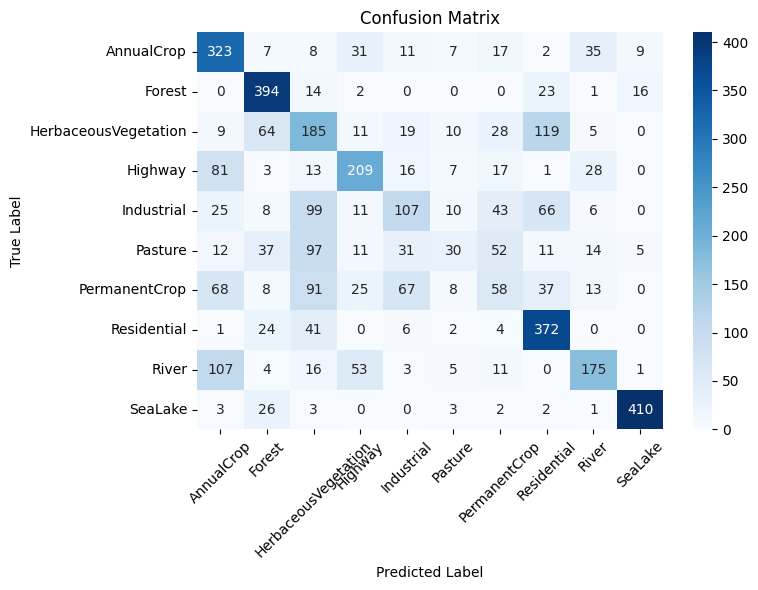

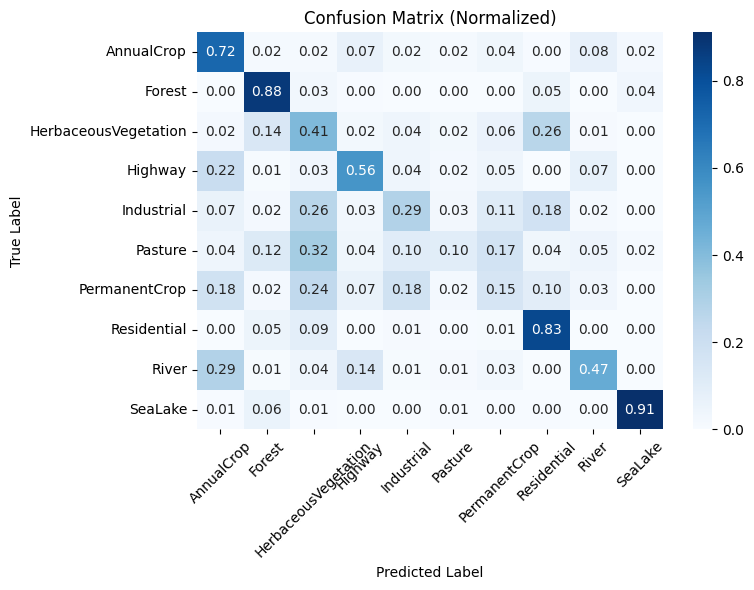

In [22]:
# Full evaluation using your existing helper
results_baseline = evaluate_model(
    Y_test,
    y_pred_baseline,
    class_names=label_encoder.classes_,
    model_name="RF Baseline"
)

## 4.4 Feature Importance

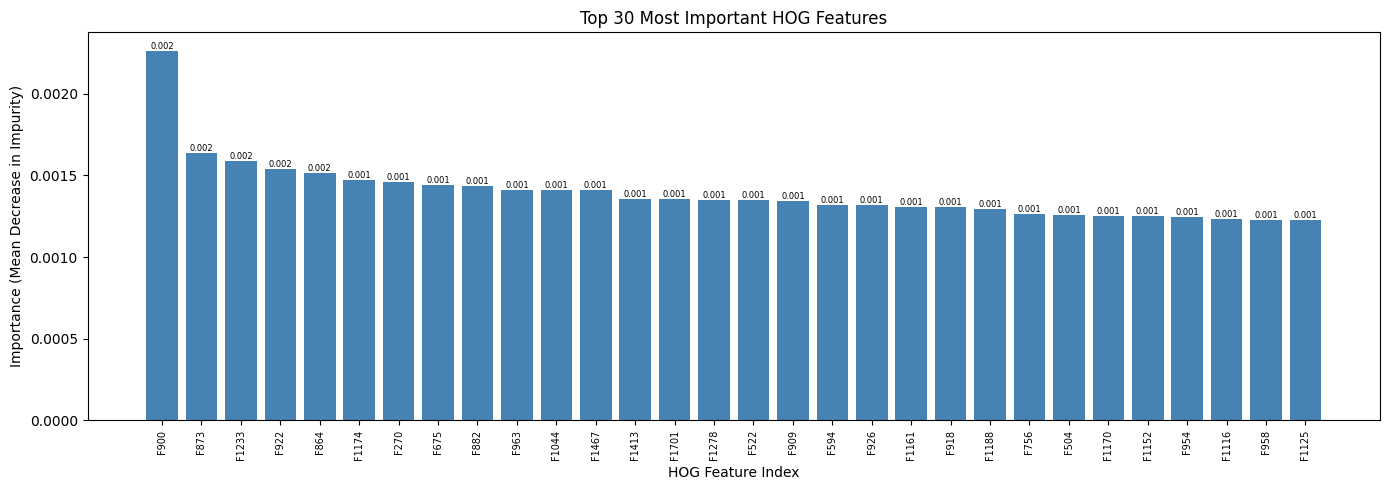

In [23]:
def plot_rf_importances(model, top_n=30):
    """
    Bar chart of top_n most important HOG features.
    Mirrors plot_importances() from the Glaucoma class notebook.
    """
    importances = model.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1][:top_n]
    sorted_imp  = importances[sorted_idx]

    plt.figure(figsize=(14, 5))
    bars = plt.bar(range(top_n), sorted_imp, color="steelblue", align="center")
    plt.xticks(range(top_n), [f"F{i}" for i in sorted_idx], rotation=90, fontsize=7)
    plt.xlabel("HOG Feature Index")
    plt.ylabel("Importance (Mean Decrease in Impurity)")
    plt.title(f"Top {top_n} Most Important HOG Features")

    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{sorted_imp[i]:.3f}", ha="center", va="bottom", fontsize=6)
    plt.tight_layout()
    plt.show()

plot_rf_importances(rf_baseline, top_n=30)

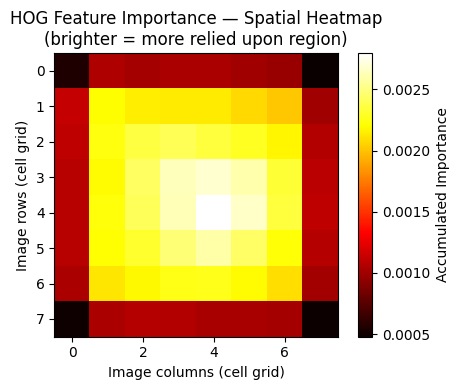

In [24]:
def plot_hog_importance_spatial(model, image_shape=(64,64),
                                 pixels_per_cell=(8,8), cells_per_block=(2,2), orientations=9):
    """
    Reshapes HOG feature importances back into a spatial heatmap.
    Brighter cells = regions the RF relies on most for classification.
    """
    importances   = model.feature_importances_
    n_cells_row   = image_shape[0] // pixels_per_cell[0]   # 8
    n_cells_col   = image_shape[1] // pixels_per_cell[1]   # 8
    n_blocks_row  = n_cells_row - cells_per_block[0] + 1   # 7
    n_blocks_col  = n_cells_col - cells_per_block[1] + 1   # 7
    feats_per_block = cells_per_block[0] * cells_per_block[1] * orientations  # 36

    spatial_map = np.zeros((n_cells_row, n_cells_col))
    feat_idx = 0

    for br in range(n_blocks_row):
        for bc in range(n_blocks_col):
            block_mean = importances[feat_idx: feat_idx + feats_per_block].mean()
            for cr in range(cells_per_block[0]):
                for cc in range(cells_per_block[1]):
                    spatial_map[br + cr, bc + cc] += block_mean
            feat_idx += feats_per_block

    plt.figure(figsize=(5, 4))
    plt.imshow(spatial_map, cmap="hot", interpolation="nearest")
    plt.colorbar(label="Accumulated Importance")
    plt.title("HOG Feature Importance — Spatial Heatmap\n(brighter = more relied upon region)")
    plt.xlabel("Image columns (cell grid)")
    plt.ylabel("Image rows (cell grid)")
    plt.tight_layout()
    plt.show()

plot_hog_importance_spatial(rf_baseline)

## 4.5 Hyperparameter Tuning Using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth"        : [10, 20, 30, None],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

rf_grid.fit(X_train_hog, Y_train)

print("\nBest hyperparameters:", rf_grid.best_params_)
print(f"Best CV accuracy:      {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [ ]:
rf_best = rf_grid.best_estimator_

print(f"OOB Score (tuned RF):    {rf_best.oob_score_:.4f}")

y_pred_grid = rf_best.predict(X_test_hog)
acc_grid    = accuracy_score(Y_test, y_pred_grid)
print(f"Test Accuracy (tuned RF): {acc_grid:.4f}")

In [ ]:
results_grid = evaluate_model(
    Y_test,
    y_pred_grid,
    class_names=label_encoder.classes_,
    model_name="RF GridSearch"
)

In [ ]:
# Feature importances of the tuned model
plot_rf_importances(rf_best, top_n=30)
plot_hog_importance_spatial(rf_best)

## 4.6 OOB Error vs Number of Trees

In [ ]:
oob_errors    = []
n_trees_range = list(range(10, 310, 10))

for n in n_trees_range:
    rf_oob = RandomForestClassifier(
        n_estimators=n,
        **rf_grid.best_params_,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_oob.fit(X_train_hog, Y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

plt.figure(figsize=(9, 4))
plt.plot(n_trees_range, oob_errors, color="darkorange", linewidth=2)
plt.axvline(x=200, color="gray", linestyle="--", label="n_estimators used (200)")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error (1 − OOB Score)")
plt.title("OOB Error vs. Number of Trees")
plt.legend()
plt.tight_layout()
plt.show()

## 4.7 Prediction Confidence & Threshold Analysis

In [ ]:
y_proba   = rf_best.predict_proba(X_test_hog)
max_proba = y_proba.max(axis=1)   # confidence = probability of the predicted class

plt.figure(figsize=(8, 4))
plt.hist(max_proba, bins=40, color="steelblue", edgecolor="white")
plt.axvline(x=0.5, color="red",    linestyle="--", label="Threshold = 0.50")
plt.axvline(x=0.7, color="orange", linestyle="--", label="Threshold = 0.70")
plt.xlabel("Max Predicted Probability (Confidence)")
plt.ylabel("Number of Test Images")
plt.title("Distribution of Prediction Confidence — RF GridSearch")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Confidence ≥ 0.5: {(max_proba >= 0.5).sum()} images ({(max_proba >= 0.5).mean():.1%})")
print(f"Confidence ≥ 0.7: {(max_proba >= 0.7).sum()} images ({(max_proba >= 0.7).mean():.1%})")

## 4.7 Per Class Analysis: Which Classes are the Hardest?

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(Y_test, y_pred_grid, normalize="true")
per_class_acc = cm.diagonal()

class_acc_df = pd.DataFrame({
    "Class"              : label_encoder.classes_,
    "Per-class Accuracy" : per_class_acc
}).sort_values("Per-class Accuracy")

colors = ["tomato" if a < 0.7 else "steelblue" for a in class_acc_df["Per-class Accuracy"]]

plt.figure(figsize=(9, 4))
bars = plt.barh(class_acc_df["Class"], class_acc_df["Per-class Accuracy"], color=colors)
plt.axvline(x=acc_grid, color="gray", linestyle="--", label=f"Overall accuracy ({acc_grid:.2%})")
plt.xlabel("Per-class Accuracy (recall)")
plt.title("Per-class Accuracy — RF GridSearch\n(red = below 70%)")
plt.xlim(0, 1)
for bar, val in zip(bars, class_acc_df["Per-class Accuracy"]):
    plt.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:.2%}", va="center", fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

print("\nWorst-performing classes:")
print(class_acc_df.head(3).to_string(index=False))

## Limitations of the Random Forest Approach

## 4.10 Results Summary

In [ ]:
# Store results for final comparison against CNN in Section 6
rf_summary = {
    "Model"        : "Random Forest (GridSearch)",
    "Features"     : "HOG (1,764 dims)",
    "n_estimators" : 200,
    "Best params"  : rf_grid.best_params_,
    "OOB Score"    : round(rf_best.oob_score_, 4),
    "Baseline Acc" : round(acc_baseline, 4),
    "Tuned Acc"    : round(acc_grid, 4),
    "Macro-F1"     : round(results_grid["macro_f1"], 4)
}

print("\n===== Random Forest Summary =====")
for k, v in rf_summary.items():
    print(f"  {k:20s}: {v}")